# Classic models (CNN) — vodič kroz notebook

Isti zadatak — prepoznavanje kompozitora po djelu — ali ovdje se ne pravi ručni feature vektor. Umjesto toga,
svaki audio segment se pretvara u **log-mel spektrogram** (2D "slika": mel frekvencija × vrijeme), i mala CNN
mreža sama uči šta u toj slici razlikuje kompozitore.

Segmenti su ovdje **10s** (`config.SEGMENT_DURATION`), kraći nego kod klasičnih modela (25s) — više trening
primjera za istu količinu audija, bitno kad imamo samo 113 djela.

PyTorch je CPU-only na ovoj mašini (nema CUDA) — trening je zato sporiji nego na GPU-u; model je namjerno
mali da to ostane izvodljivo.

In [1]:
%load_ext autoreload
%autoreload 2

# Ucitavanje podataka

## Učitavanje i pregled metapodataka

`metadata` je tabela u kojoj svaki red opisuje jedan audio zapis / stav: kompozitora, djelo, stav, ansambl,
trajanje itd. Naredne ćelije prvo provjeravaju nedostajuće vrijednosti i spisak kompozitora, a tek onda
odlučuju koje klase ostaju u eksperimentu.

Putanje `AUDIO_DIR` i `METADATA_PATH` su lokalne putanje sa računara na kojem je notebook pisan; na drugom
računaru moraju da pokazuju na odgovarajuću lokaciju MusicNet fajlova.


In [1]:
import numpy as np
import pandas as pd

from paths import AUDIO_DIR, METADATA_PATH

metadata = pd.read_csv(METADATA_PATH)

print(metadata.head())
print(metadata.columns)

     id  composer               composition                   movement  \
0  1727  Schubert  Piano Quintet in A major                 2. Andante   
1  1728  Schubert  Piano Quintet in A major         3. Scherzo: Presto   
2  1729  Schubert  Piano Quintet in A major  4. Andantino - Allegretto   
3  1730  Schubert  Piano Quintet in A major          5. Allegro giusto   
4  1733  Schubert   Piano Sonata in A major               2. Andantino   

        ensemble            source                      transcriber  \
0  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
1  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
2  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
3  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
4     Solo Piano          Museopen                Segundo G. Yogore   

  catalog_name  seconds  
0        OP114      447  
1        OP114      251  
2        OP114      444  
3        OP114      368 

In [2]:
metadata.isna().sum()
# No missing values

id              0
composer        0
composition     0
movement        0
ensemble        0
source          0
transcriber     0
catalog_name    0
seconds         0
dtype: int64

In [3]:
metadata["composer"].unique()
# We have 10 composers

<StringArray>
[ 'Schubert',    'Mozart',    'Dvorak',   'Cambini',     'Haydn',    'Brahms',
     'Faure',     'Ravel',      'Bach', 'Beethoven']
Length: 10, dtype: str

In [4]:
metadata["composer"].value_counts()

composer
Beethoven    157
Bach          67
Schubert      30
Mozart        24
Brahms        24
Cambini        9
Dvorak         8
Faure          4
Ravel          4
Haydn          3
Name: count, dtype: int64

## Zašto se pravi `work_id`?

Jedno muzičko djelo može imati više stavova, a u metapodacima su oni posebni redovi. Kombinacijom
`composer + composition` pravi se identifikator cijelog djela. Tako npr. više stavova iste sonate ostaju ista
grupa tokom cross-validationa.

Nakon toga se broji broj **različitih djela po kompozitoru**, ne broj segmenata. Kompozitori sa manje od 5
djela se uklanjaju jer bi grupni cross-validation za njih bio vrlo nestabilan.


In [5]:
metadata["work_id"] = (
    metadata["composer"].astype(str)
    + " | "
    + metadata["composition"].astype(str)
)

# Adding a column so we can group the same composition from different movements

In [6]:
work_counts = (
    metadata.groupby("composer")["work_id"]
    .nunique()
)

print(work_counts)

# We will remove all the composers that have less than 5 compositions in the dataset, also we can see our dataset is inbalanced

composer
Bach         30
Beethoven    55
Brahms        8
Cambini       3
Dvorak        2
Faure         1
Haydn         1
Mozart       11
Ravel         1
Schubert      9
Name: work_id, dtype: int64


In [7]:
valid_composers = work_counts[
    work_counts >= 5
].index

metadata_filtered = metadata[
    metadata["composer"].isin(valid_composers)
].copy()

# Filtering the composers

In [8]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Mel-spektrogram dataset

`make_spectrogram_dataset` (u `spectrograms.py`) radi isto što i `make_dataset`/`make_midi_dataset` — učita
audio, isiječe na segmente, ali umjesto ručnih atributa računa `extract_melspec` (128 mel binova ×
~862 vremenskih frame-ova po segmentu, log-dB skala). Rezultat je keširan na disk (invalidira se automatski
ako se promijeni `spectrograms.py`).

Pošto su `SEGMENT_DURATION == MIN_LAST_DURATION == 10`, zadržavaju se samo puni 10s segmenti — svi imaju
identičnu dužinu, pa je `X` običan 3D numpy niz (N, 128, T), bez potrebe za paddingom.

In [9]:
from spectrograms import make_spectrogram_dataset

X, y, groups = make_spectrogram_dataset(metadata_filtered, AUDIO_DIR)

print(X.shape)

Processing spectrograms:   0%|          | 0/302 [00:00<?, ?it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing spectrograms: 100%|██████████| 302/302 [38:48<00:00,  7.71s/it]


(11096, 128, 862)


---

## Train/val split

Pun 5-fold `StratifiedGroupKFold` (kao kod klasičnih modela) bi značio 5x treniranje CNN-a — na CPU-u
predugo za iterativno eksperimentisanje. Za sada radimo **jedan** group-aware split (`GroupShuffleSplit` —
segmenti istog `work_id` ne smiju biti i u train i u val). Kad se arhitektura/hiperparametri skoro finalizuju,
vrijedi ponoviti sa punim CV radi pouzdanije ocjene.

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

from evaluation import make_sample_weights, soft_vote_predictions

le = LabelEncoder()
y_enc = le.fit_transform(y)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_enc, groups))

X_train, y_train, groups_train = X[train_idx], y_enc[train_idx], groups[train_idx]
X_val, y_val, groups_val = X[val_idx], y[val_idx], groups[val_idx]

sample_weights = make_sample_weights(y[train_idx], groups_train)

print("train segments:", len(X_train), "val segments:", len(X_val))

train segments: 8919 val segments: 2177


---

## Model i trening

Mali CNN (`SimpleCNN` u `nn_utils.py`): 3 conv+BN+ReLU+maxpool bloka, pa global average pooling i dropout
prije finalnog linearnog sloja — namjerno malo parametara zbog svega 113 djela. `SpecAugment` (nasumično
maskiranje frekvencijskih/vremenskih traka) je uključen samo na trening skupu, kao augmentacija.
`sample_weights` (isti mehanizam kao kod klasičnih modela) ide kroz `WeightedRandomSampler`, umjesto direktno
u loss funkciju.

device: cpu


epoch 1/20: 100%|██████████| 279/279 [12:07<00:00,  2.61s/it, acc=0.376, loss=1.41]


epoch 1/20: train_loss=1.4102 train_acc=0.3756 val_loss=1.5642 val_acc=0.3353


epoch 2/20: 100%|██████████| 279/279 [11:22<00:00,  2.45s/it, acc=0.464, loss=1.26]


epoch 2/20: train_loss=1.2623 train_acc=0.4640 val_loss=1.5109 val_acc=0.2168


...

epoch 18/20: train_loss=0.8120 train_acc=0.6782 val_loss=2.3279 val_acc=0.1980


epoch 19/20: 100%|██████████| 279/279 [13:01<00:00,  2.80s/it, acc=0.679, loss=0.798]


epoch 19/20: train_loss=0.7977 train_acc=0.6791 val_loss=1.7201 val_acc=0.2797


epoch 20/20: 100%|██████████| 279/279 [12:07<00:00,  2.61s/it, acc=0.682, loss=0.796]


epoch 20/20: train_loss=0.7962 train_acc=0.6820 val_loss=1.6076 val_acc=0.3179


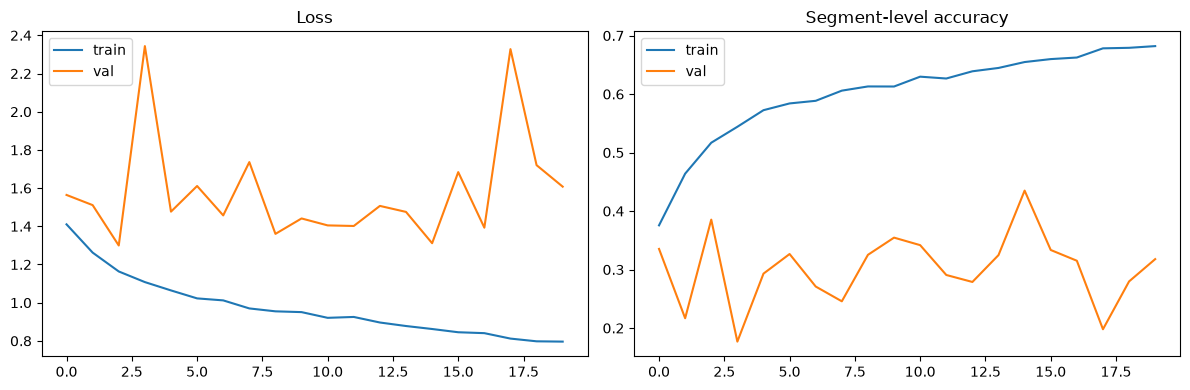

In [11]:
import torch

from nn_utils import SpectrogramDataset, SimpleCNN, train_model, plot_history

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

train_ds = SpectrogramDataset(X_train, y_train, augment=True)
val_ds = SpectrogramDataset(X_val, le.transform(y_val), augment=False)

model = SimpleCNN(n_classes=len(le.classes_))

history = train_model(
    model, train_ds, val_ds,
    sample_weights=sample_weights,
    epochs=20,
    batch_size=32,
    lr=1e-3,
    device=device
)

plot_history(history)

---

## Work-level evaluacija

Model predviđa po segmentu; `soft_vote_predictions` (ista funkcija iz `evaluation.py` koju smo definisali za
klasične modele, do sad neiskorištena) prosječi softmax vjerovatnoće svih segmenata jednog djela i uzme
najvjerovatniju klasu — konzistentno sa `majority_vote_prediction` pristupom kod ostalih modela, samo
iskorišćava i "koliko je model siguran", ne samo tvrdu predikciju.

              precision    recall  f1-score   support

        Bach       1.00      0.71      0.83         7
   Beethoven       1.00      0.17      0.29        12
      Brahms       0.14      1.00      0.25         1
      Mozart       0.00      0.00      0.00         1
    Schubert       0.14      0.50      0.22         2

    accuracy                           0.39        23
   macro avg       0.46      0.48      0.32        23
weighted avg       0.84      0.39      0.43        23



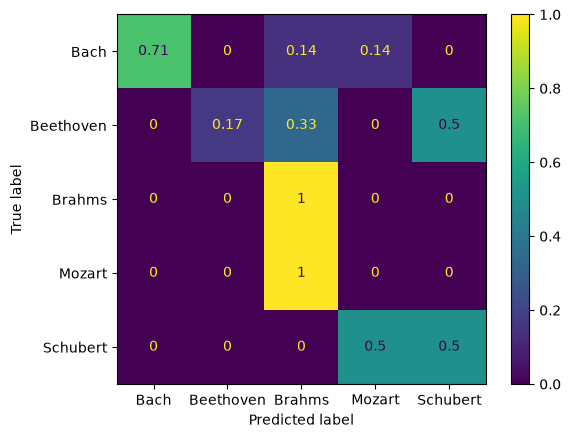

In [12]:
from sklearn import metrics
from matplotlib import pyplot as plt

from nn_utils import predict_probs

probs = predict_probs(model, X_val, device=device)

work_true, work_pred = soft_vote_predictions(y_val, probs, groups_val, le.classes_)

print(metrics.classification_report(work_true, work_pred))

metrics.ConfusionMatrixDisplay.from_predictions(work_true, work_pred, normalize="true")
plt.show()